In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/scratch2/jsb92/20250523_HeLa_STORM/Cell3_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
analysis_files = H_F.file_search(image_folder, ".h5", "")

In [5]:
analysed_data = pd.read_hdf(analysis_files[0])

In [91]:
analysed_data_copy = analysed_data
for param in analysed_data:
    if ("err" in param) or ("chi" in param):
        analysed_data_copy = analysed_data_copy[
            analysed_data_copy[param] < np.median(analysed_data[param]) * 3
        ]

analysed_data_copy = analysed_data_copy[analysed_data_copy["A_G"] > 100]
analysed_data_copy = analysed_data_copy[analysed_data_copy["A_R"] > 100]
analysed_data_copy = analysed_data_copy[analysed_data_copy["A_B"] > 100]

analysed_data_copy = analysed_data_copy[analysed_data_copy["A_G"] < 1e4]
analysed_data_copy = analysed_data_copy[analysed_data_copy["A_R"] < 1e4]
analysed_data_copy = analysed_data_copy[analysed_data_copy["A_B"] < 1e4]

analysed_data_copy = analysed_data_copy[analysed_data_copy["s_x"] > 1]
analysed_data_copy = analysed_data_copy[analysed_data_copy["s_y"] > 1]

sbr = (
    analysed_data_copy["A_R"] + analysed_data_copy["A_G"] + analysed_data_copy["A_B"]
) / (
    analysed_data_copy["bg_R"] + analysed_data_copy["bg_G"] + analysed_data_copy["bg_B"]
)
analysed_data_copy = analysed_data_copy[sbr > 20]

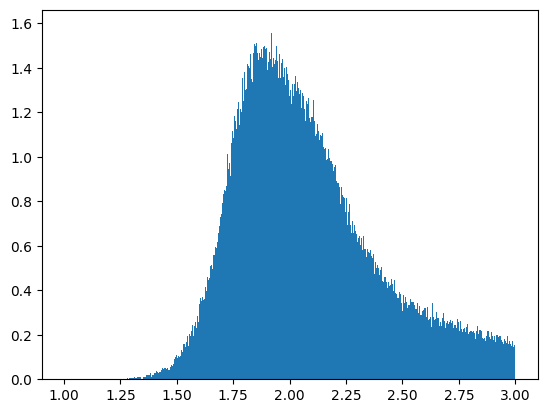

In [92]:
plt.hist(analysed_data_copy["s_x"], 1000, density=True)
plt.show()

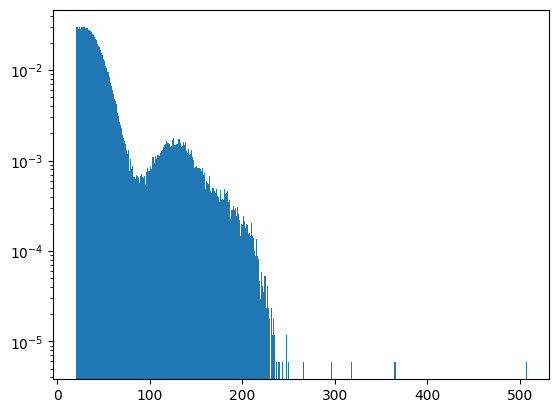

In [93]:
plt.hist(
    (analysed_data_copy["A_R"] + analysed_data_copy["A_G"] + analysed_data_copy["A_B"])
    / (
        analysed_data_copy["bg_R"]
        + analysed_data_copy["bg_G"]
        + analysed_data_copy["bg_B"]
    ),
    1000,
    density=True,
)
plt.yscale("log")
plt.show()

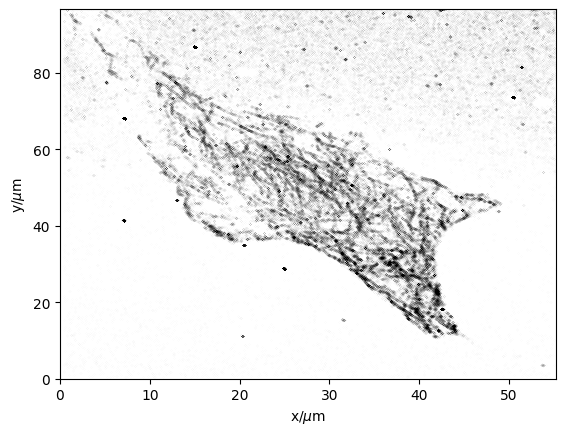

In [108]:
plt.scatter(
    analysed_data_copy["xc"] * 0.069,
    analysed_data_copy["yc"] * 0.069,
    s=0.001,
    alpha=0.25,
    color="k",
)
plt.ylim([0, 1400 * 0.069])
plt.xlim([0, 800 * 0.069])

plt.xlabel(r"x/$\mu$m")
plt.ylabel(r"y/$\mu$m")
plt.savefig("example.png", dpi=600, format="png")
plt.show()

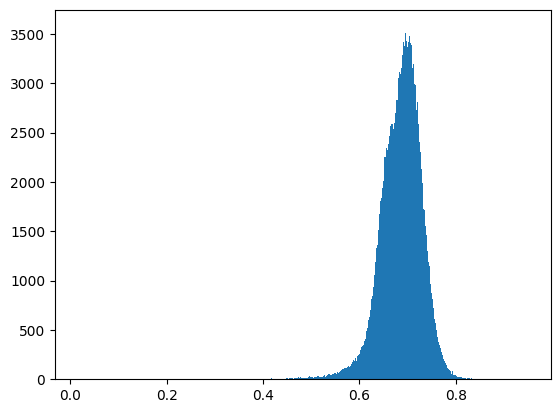

In [95]:
plt.hist(
    analysed_data_copy["A_R"]
    / (
        analysed_data_copy["A_R"]
        + analysed_data_copy["A_G"]
        + analysed_data_copy["A_B"]
    ),
    1000,
)
plt.show()

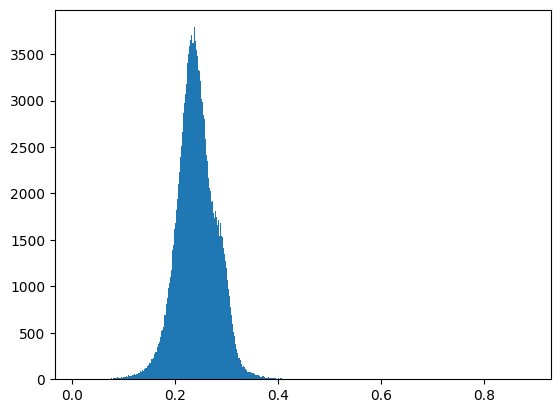

In [96]:
plt.hist(
    analysed_data_copy["A_G"]
    / (
        analysed_data_copy["A_R"]
        + analysed_data_copy["A_G"]
        + analysed_data_copy["A_B"]
    ),
    1000,
)
plt.show()

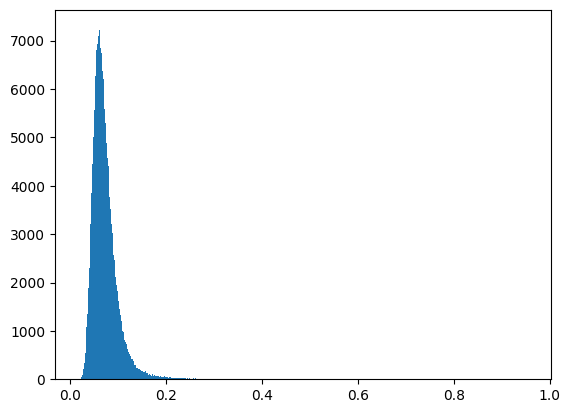

In [97]:
plt.hist(
    analysed_data_copy["A_B"]
    / (
        analysed_data_copy["A_R"]
        + analysed_data_copy["A_G"]
        + analysed_data_copy["A_B"]
    ),
    1000,
)
plt.show()